In [1]:
from torch_snippets_local import *
from torch import nn, optim
from torchvision import transforms
import torchvision.utils as vutils
import cv2
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision
import warnings
import configparser
warnings.filterwarnings('ignore')
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [2]:
config = configparser.ConfigParser()
config.read('config.ini')
# Load parameters from config file
#root = '/Users/leonjye/Documents/MachineLearingData'
root = config.get('DEFAULT', 'root_dir')
image_dir = os.path.join(root, 'GenderDetection','train')
image_dir

'/Users/leonjye/Documents/MachineLearingData/GenderDetection/train'

In [3]:
'''
female_images = Glob(os.path.join(image_dir, 'women', '*.jpg'))
male_images = Glob(os.path.join(image_dir, 'men', '*.jpg'))
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
'''

"\nfemale_images = Glob(os.path.join(image_dir, 'women', '*.jpg'))\nmale_images = Glob(os.path.join(image_dir, 'men', '*.jpg'))\nface_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')\n"

In [4]:
'''
for i in range(len(female_images)):
    img = readImage2RGB(female_images[i])
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x,y,w,h) in faces:
        img2 = img[y:(y+h),x:(x+w),:]
    cv2.imwrite('cropped_faces_female/'+str(i)+'.jpg',cv2.cvtColor(img2, cv2.COLOR_RGB2BGR))
for i in range(len(male_images)):
    img = readImage2RGB(male_images[i])
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x,y,w,h) in faces:
        img2 = img[y:(y+h),x:(x+w),:]
    cv2.imwrite('cropped_faces_male/'+str(i)+'.jpg',cv2.cvtColor(img2, cv2.COLOR_RGB2BGR))
'''

"\nfor i in range(len(female_images)):\n    img = readImage2RGB(female_images[i])\n    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)\n    faces = face_cascade.detectMultiScale(gray, 1.3, 5)\n    for (x,y,w,h) in faces:\n        img2 = img[y:(y+h),x:(x+w),:]\n    cv2.imwrite('cropped_faces_female/'+str(i)+'.jpg',cv2.cvtColor(img2, cv2.COLOR_RGB2BGR))\nfor i in range(len(male_images)):\n    img = readImage2RGB(male_images[i])\n    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)\n    faces = face_cascade.detectMultiScale(gray, 1.3, 5)\n    for (x,y,w,h) in faces:\n        img2 = img[y:(y+h),x:(x+w),:]\n    cv2.imwrite('cropped_faces_male/'+str(i)+'.jpg',cv2.cvtColor(img2, cv2.COLOR_RGB2BGR))\n"

In [5]:
transform=transforms.Compose([
                               transforms.Resize(64),
                               transforms.CenterCrop(64),
                               transforms.ToTensor(),
                               transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                           ])

In [6]:
class Faces(Dataset):
    def __init__(self, folders):
        super().__init__()
        self.folderfemale = folders[0]
        self.foldermale = folders[1]
        self.images=sorted(Glob(self.folderfemale))+sorted(Glob(self.foldermale))
    def __len__(self):
        return len(self.images)
    def __getitem__(self, ix):
        image_path = self.images[ix]
        image = Image.open(image_path)
        image = transform(image)
        gender = np.where('female' in str(image_path),1,0)
        return image, torch.tensor(gender).long()

In [7]:
ds = Faces(folders=['cropped_faces_female','cropped_faces_male'])
dataloader = DataLoader(ds, batch_size=128, shuffle=True, num_workers=0)

found 90 files in cropped_faces_female
found 92 files in cropped_faces_male


In [8]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [9]:
class Discriminator(nn.Module):
    def __init__(self, emb_size=32):
        super(Discriminator, self).__init__()
        self.emb_size = emb_size
        self.label_embeddings = nn.Embedding(2, self.emb_size)
        self.model = nn.Sequential(
            nn.Conv2d(3,64,4,2,1,bias=False),
            nn.LeakyReLU(0.2,inplace=True),
            nn.Conv2d(64,64*2,4,2,1,bias=False),
            nn.BatchNorm2d(64*2),
            nn.LeakyReLU(0.2,inplace=True),
            nn.Conv2d(64*2,64*4,4,2,1,bias=False),
            nn.BatchNorm2d(64*4),
            nn.LeakyReLU(0.2,inplace=True),
            nn.Conv2d(64*4,64*8,4,2,1,bias=False),
            nn.BatchNorm2d(64*8),
            nn.LeakyReLU(0.2,inplace=True),
            nn.Conv2d(64*8,64,4,2,1,bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2,inplace=True),
            nn.Flatten()
        )
        self.model2 = nn.Sequential(
            nn.Linear(288,100),
            nn.LeakyReLU(0.2,inplace=True),
            nn.Linear(100,1),
            nn.Sigmoid()
        )
        self.apply(weights_init)
    def forward(self, input, labels):
        x = self.model(input)
        y = self.label_embeddings(labels)
        input = torch.cat([x, y], 1)
        final_output = self.model2(input)
        return final_output

In [10]:
from torchsummary import summary
discriminator = Discriminator().to(device)
#summary(discriminator, [(3,64,64),(torch.zeros(32, dtype=torch.long))], device=device)
#summary(discriminator,torch.zeros(32,3,64,64).to(device), torch.zeros(32).long().to(device));

In [11]:
class Generator(nn.Module):
    def __init__(self, emb_size=32):
        super(Generator,self).__init__()
        self.emb_size = emb_size
        self.label_embeddings = nn.Embedding(2, self.emb_size)
        self.model = nn.Sequential(
            nn.ConvTranspose2d(100+self.emb_size,64*8,4,1,0,bias=False),
            nn.BatchNorm2d(64*8),
            nn.ReLU(True),
            nn.ConvTranspose2d(64*8,64*4,4,2,1,bias=False),
            nn.BatchNorm2d(64*4),
            nn.ReLU(True),
            nn.ConvTranspose2d(64*4,64*2,4,2,1,bias=False),
            nn.BatchNorm2d(64*2),
            nn.ReLU(True),
            nn.ConvTranspose2d(64*2,64,4,2,1,bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64,3,4,2,1,bias=False),
            nn.Tanh()
        )
        self.apply(weights_init)
    def forward(self,input_noise,labels):
        label_embeddings = self.label_embeddings(labels).view(len(labels), self.emb_size, 1, 1)
        input = torch.cat([input_noise, label_embeddings], 1)
        return self.model(input)

In [12]:
generator = Generator().to(device)
#summary(generator,torch.zeros(32,100,1,1).to(device), torch.zeros(32).long().to(device));

In [13]:
def noise(size):
    n = torch.randn(size, 100, 1, 1, device=device)
    return n.to(device)

In [14]:
discriminator = Discriminator().to(device)
generator = Generator().to(device)
loss = nn.BCELoss()
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
loss = nn.BCELoss()
n_epochs = 25
img_list = []

In [15]:
def discriminator_train_step(real_data, real_labels, fake_data, fake_labels):
    d_optimizer.zero_grad()
    prediction_real = discriminator(real_data, real_labels)
    error_real = loss(prediction_real, torch.ones(len(real_data), 1).to(device))
    error_real.backward()
    prediction_fake = discriminator(fake_data, fake_labels)
    error_fake = loss(prediction_fake, torch.zeros(len(fake_data), 1).to(device))
    error_fake.backward()
    d_optimizer.step()    
    return error_real + error_fake

In [16]:
def generator_train_step(fake_data, fake_labels):
    g_optimizer.zero_grad()
    prediction = discriminator(fake_data, fake_labels)
    error = loss(prediction, torch.ones(len(fake_data), 1).to(device))
    error.backward()
    g_optimizer.step()
    return error

In [17]:
#log = Report(n_epochs)
fixed_noise = torch.randn(64, 100, 1, 1, device=device)
fixed_fake_labels = torch.LongTensor([0]*(len(fixed_noise)//2) + [1]*(len(fixed_noise)//2)).to(device)
fixed_fake_labels

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

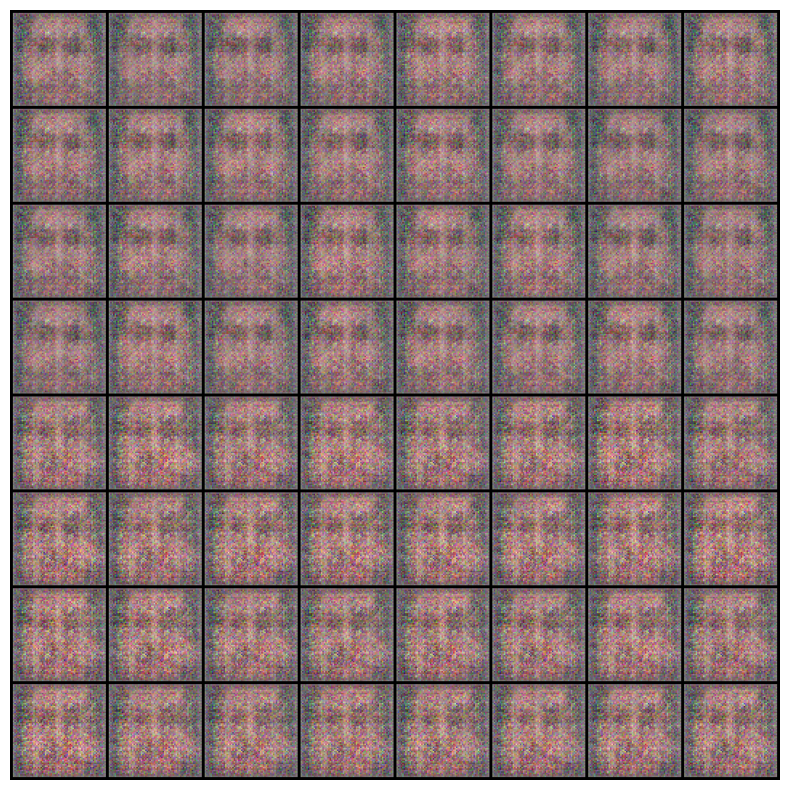

In [18]:
for epoch in range(n_epochs):
    N = len(dataloader)
    for bx, (images, labels) in enumerate(dataloader):
        real_data, real_labels = images.to(device), labels.to(device)
        fake_labels = torch.LongTensor(np.random.randint(0, 2, len(real_data))).to(device)
        fake_data = generator(noise(len(real_data)), fake_labels)
        fake_data = fake_data.detach()
        d_loss = discriminator_train_step(real_data, real_labels, fake_data, fake_labels)
        fake_labels = torch.LongTensor(np.random.randint(0, 2, len(real_data))).to(device)
        fake_data = generator(noise(len(real_data)), fake_labels).to(device)
        g_loss = generator_train_step(fake_data, fake_labels)
        pos = epoch + (1+bx)/N
        #log.record(pos, d_loss=d_loss.detach(), g_loss=g_loss.detach(), end='\r')
        print(f'\rEpoch {epoch+1}/{n_epochs} [{bx+1}/{N}] D Loss: {d_loss:.4f} G Loss: {g_loss:.4f}', end='\r')   
    #log.report_avgs(epoch+1)
with torch.no_grad():
    fake = generator(fixed_noise, fixed_fake_labels).detach().cpu()
    imgs = vutils.make_grid(fake, padding=2, normalize=True).permute(1,2,0)
    img_list.append(imgs)
    simple_show(imgs, sz=10)